# Plasmotype Association Study (PAS) — minimal reproduction
**Paper:** Theeuwen et al. 2024, *"Species wide inventory of *Arabidopsis thaliana* organellar variation reveals ample phenotypic variation for photosynthetic performance"* (bioRxiv 2024.07.12.603232).

**Reproduced scope (partial demonstration):** the paper's Plasmotype Association Study. We rebuild the PLINK binary files from the 40X-filtered chloroplast VCF of the 60 progenitor plasmotypes, insert the DEPI plasmotype main effects into the `.fam` file with the authors' own R script, run GEMMA univariate LMM associations for a representative subset of the 1986 DEPI traits, and draw a Manhattan plot with the Bonferroni threshold derived from the number of unique chloroplast variant combinations (313 → −log₁₀(0.05/313) ≈ 3.8, matching the paper's 3.8 LOD threshold).

**Not reproduced here:** the full 1986-trait sweep with GNU `parallel` (the notebook runs 9 traits; the per-trait command is identical), the MAF 0.04 sweep (same mechanics), the 1,531-accession nuclear GWAS (VCF only on request from the author), and all wet-lab/cybrid-construction steps.

**Execution status:** CPU-only notebook (no GPU needed — 60 samples, ≤7,041 chloroplast SNPs, GEMMA LMM is trivially small). All data and binaries are downloaded inside Colab; nothing is read from the DGX host.

日本語の概要：本ノートブックは Theeuwen et al. (2024) のプラズモタイプ関連解析（PAS）の最小再現です。60 プラズモタイプの葉緑体 VCF から PLINK bed/bim/fam を再構築し、著者らの R スクリプトで DEPI 表現型を `.fam` に統合し、GEMMA 一変量 LMM を 9 性状について実行、 Bonferroni 閾値（≈3.8）付きマンハッタンプロットを描きます。完全な 1986 性状スイープや核 GWAS は対象外です。

## 0. Runtime selection
This reproduction is CPU-only. PLINK 1.9 and GEMMA are single-threaded classical statistics tools; the dataset is 60 individuals × ≤7,041 biallelic chloroplast SNPs, so a standard Colab CPU runtime is faithful and completes in minutes. **Select Runtime → Change runtime type → CPU (Standard).** Expected wall time ≈ 5–10 min; downloads ≈ 45 MB (Zenodo zip 29.8 MB + plink/gemma binaries).

## 1. Tool setup — PLINK 1.9
Download the official PLINK 1.9 Linux binary (cog-genomics build of 27 Sep 2026, the current 1.9 release) and verify it runs. The author's log book (`5. Plasmotype Association Studies/1. Log book command line.txt` in git.wur.nl/tom.theeuwen/novel-cybrids) uses PLINK 1.9 command syntax.

In [ ]:
import subprocess, urllib.request, zipfile, os
if not os.path.exists('tools/plink'):
    urllib.request.urlretrieve('https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20260927.zip', 'plink.zip')
    zipfile.ZipFile('plink.zip').extractall('tools/')
    os.chmod('tools/plink', 0o755)
print(subprocess.run(['tools/plink','--version'], capture_output=True, text=True).stdout.strip())

PLINK v1.9.0 64-bit (27 Sep 2026)


## 2. Tool setup — GEMMA 0.98.5
Download the static GEMMA v0.98.5 Linux binary (official genetics-statistics GitHub release) and verify it runs. The author's log book does not pin a GEMMA version; 0.98.5 is the current release and reproduces the authors' saved results (checked below).

In [ ]:
import gzip, shutil
if not os.path.exists('tools/gemma'):
    urllib.request.urlretrieve('https://github.com/genetics-statistics/GEMMA/releases/download/v0.98.5/gemma-0.98.5-linux-static-AMD64.gz', 'gemma.gz')
    with gzip.open('gemma.gz','rb') as fi, open('tools/gemma','wb') as fo: shutil.copyfileobj(fi, fo)
    os.chmod('tools/gemma', 0o755)
print(subprocess.run(['tools/gemma','--version'], capture_output=True, text=True).stdout.strip())

error! unrecognized option: --version
GEMMA 0.98.5 (2021-08-25) by Xiang Zhou, Pjotr Prins and team (C) 2012-2021


## 3. Data acquisition — Zenodo record 11259865 (CC-BY-4.0)
The paper's data are published on Zenodo (doi:10.5281/zenodo.11259865). We download only the 29.8 MB zip `5. Plasmotype Association Studies.zip`, which contains the filtered 60-cybrid chloroplast VCF, the DEPI additive BLUE phenotype table, and — importantly for validation — the authors' own saved pipeline outputs (`*_additive_phenotypes.fam`, kinship matrix, `sumarizing_PAS_results_MAF_0.csv`). We keep only the members this reproduction needs.

In [ ]:
import zipfile
BASE = '5. Plasmotype Association Studies/'
if not os.path.exists('pas.zip'):
    urllib.request.urlretrieve('https://zenodo.org/records/11259865/files/5.%20Plasmotype%20Association%20Studies.zip?download=1', 'pas.zip')
MEMBERS = [
    'chrPt_Complete_60_cybrids_QD25_filtred_pass_50%_Heterozygous_pipes_replaced.recode.vcf',
    'DEPI_additive_BLUEs.csv',
    'data_unique_combinations.csv',
    'sumarizing_PAS_results_MAF_0.csv',
    'chrPt_Complete_60_cybrids_QD25_filtred_pass_50%_Heterozygous_pipes_replaced_additive_phenotypes.fam',
    'chrPt_Complete_60_cybrids_QD25_filtred_pass_50%_Heterozygous_pipes_replaced_full_kinship.cXX.txt',
]
z = zipfile.ZipFile('pas.zip')
for name in MEMBERS:
    z.extract(BASE + name, 'ext')
print('extracted', len(MEMBERS), 'members; zip size', os.path.getsize('pas.zip'), 'bytes')

extracted 6 members; zip size 29818732 bytes


## 4. Input preview — chloroplast VCF
Show the VCF basics: sample count, sample names, and variant count. This is the actual reproduction input (13.9 MB, 60 samples, QD≥25 filtered, >50%-heterozygous accessions removed, phasing pipes replaced with '/'). PLINK cannot open paths containing spaces, so we copy it to a flat name first.

In [ ]:
import shutil
VCF = 'ext/' + BASE + 'chrPt_Complete_60_cybrids_QD25_filtred_pass_50%_Heterozygous_pipes_replaced.recode.vcf'
shutil.copy(VCF, 'chrPt60.vcf')
n_var = 0
with open('chrPt60.vcf') as f:
    for line in f:
        if line.startswith('#CHROM'):
            samples = line.rstrip().split('\t')[9:]
        elif not line.startswith('#'):
            n_var += 1
print('samples:', len(samples))
print('first 8:', samples[:8])
print('variant lines:', n_var)

samples: 60
first 8: ['C24_Cybrid', 'Ws-4_Cybrid', 'Ely_Cybrid', 'Madeira_13', 'Elh-2', 'Taz-0', 'Bab-0', 'Zin-9']
variant lines: 7041


## 5. Input preview — DEPI additive BLUE phenotypes
`DEPI_additive_BLUEs.csv` holds 59 plasmotypes × 1986 DEPI-derived additive BLUE traits (columns `Cybrid_allfvfm_*` are chlorophyll-fluorescence traits measured over a time series; many entries are NA where a plasmotype was not phenotyped). Display the first rows.

In [ ]:
import pandas as pd
ph = pd.read_csv('ext/' + BASE + 'DEPI_additive_BLUEs.csv')
print('shape:', ph.shape)
print('first columns:', ph.columns[:5].tolist())
ph.iloc[:5, :4]

shape: (59, 1987)
first columns: ['Plasmotype', 'Cybrid_allfvfm_0.0', 'Cybrid_allfvfm_24.0', 'Cybrid_allfvfm_48.0', 'Cybrid_allfvfm_72.0']


,Plasmotype,Cybrid_allfvfm_0.0,Cybrid_allfvfm_24.0,Cybrid_allfvfm_48.0
0,Agl-0,NaN,NaN,NaN
1,Agl-5,NaN,NaN,NaN
2,Aitba-1,0.810427,0.808721,0.807958
3,Bab-0,0.811080,0.810154,0.808006
4,Basta-2,0.809431,0.809705,0.807042


## 6. Step 1 (log book) — build PLINK bed/bim/fam from the VCF
Run the authors' exact command: `plink --vcf <vcf> --allow-extra-chr --make-bed --recode --out chrPt_Complete_60_cybrids_QD25_filtred_pass_50%_Heterozygous_pipes_replaced`. PLINK 1.9 splits VCF sample names at the first underscore into FID/IID (e.g. `C24_Cybrid` → FID `C24`, IID `Cybrid`), which reproduces the authors' `.fam` convention.

In [ ]:
prefix = 'chrPt_Complete_60_cybrids_QD25_filtred_pass_50%_Heterozygous_pipes_replaced'
r = subprocess.run(['tools/plink', '--vcf', 'chrPt60.vcf', '--allow-extra-chr',
                    '--make-bed', '--recode', '--out', prefix],
                   capture_output=True, text=True)
print(r.stdout[-700:]); print('STDERR:', r.stderr[-300:])
print('bim variants:', sum(1 for _ in open(prefix + '.bim')))
print(open(prefix + '.fam').read().splitlines()[:4])

rozygous_pipes_replaced.ped
+
chrPt_Complete_60_cybrids_QD25_filtred_pass_50%_Heterozygous_pipes_replaced.map
... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66%67%68%69%70%71%72%73%74%75%76%77%78%79%80%81%82%83%84%85%86%87%88%89%90%91%92%93%94%95%96%97%98%99%done.

STDERR: 
bim variants: 7041
['C24 Cybrid 0 0 0 -9', 'Ws-4 Cybrid 0 0 0 -9', 'Ely Cybrid 0 0 0 -9', 'Madeira 13 0 0 0 -9']


## 7. Step 2 (log book) — author's R script: phenotypes into the .fam file
Run the authors' unmodified R script `2. Phenotypes to fam.R` (fetched from the pinned repository revision; only its `setwd()` line is pointed to `/content`). It sorts the 60 fam rows by FID, sorts the DEPI table by plasmotype (appending an all-NA `Ely` row), cbinds them positionally, renames `Ara-1`→`Shah`, and restores the original fam order. This is the authors' own code, not a reimplementation.

In [ ]:
import urllib.request
raw = 'https://git.wur.nl/tom.theeuwen/novel-cybrids/-/raw/main/5.%20Plasmotype%20Association%20Studies/2.%20Phenotypes%20to%20fam.R'
script = urllib.request.urlopen(raw).read().decode()
script = script.replace('setwd("/Users/tomtheeuwen/OneDrive - Wageningen University & Research/PD_Year_1/New cybrids manuscript/Data/5. Plasmotype Association Studies/Only upload/")', 'setwd("/content")')
open('phenotypes_to_fam.R', 'w').write(script)
print(script[:260])

library(readr)
setwd("/content")

famfile <- read.table("chrPt_Complete_60_cybrids_QD25_filtred_pass_50%_Heterozygous_pipes_replaced.fam")
famfile[which(famfile$V1 == "Ara-1"),1] <- "Shah"
famfile <- famfile[,1:5]
famfile$to_order <- c(1:60)
famfile <- famfile


Install the `readr` package (used by the script's `write_tsv`) and execute the patched author script with Rscript. R 4.x is preinstalled in Colab runtime images.

In [ ]:
import shutil
shutil.copy(prefix + '.fam', prefix + '.fam.keep')  # keep a copy of the plink fam under the name the R script reads
shutil.copy('ext/' + BASE + 'DEPI_additive_BLUEs.csv', 'DEPI_additive_BLUEs.csv')  # the author script reads this from its working directory
r = subprocess.run(['/usr/bin/Rscript', '-e',
                    'install.packages("readr",repos="https://cloud.r-project.org",quiet=TRUE);library(readr)'],
                   capture_output=True, text=True, timeout=900)
print('readr install:', r.returncode)
r = subprocess.run(['/usr/bin/Rscript', 'phenotypes_to_fam.R'], capture_output=True, text=True, timeout=900)
print('R exit:', r.returncode); print(r.stdout[-300:]); print(r.stderr[-300:])

readr install: 0


R exit: 0




Validate step 2: the produced fam must be **byte-identical** to the authors' saved `..._additive_phenotypes.fam` in the Zenodo zip.

In [ ]:
merged = prefix + '_additive_phenotypes.fam'
mine = open(merged, 'rb').read()
auth = open('ext/' + BASE + merged, 'rb').read()
print('byte-identical to authors saved fam:', mine == auth, f'({len(mine)} bytes)')

byte-identical to authors saved fam: True (1745186 bytes)


## 8. Step 3 (log book) — GEMMA kinship matrix
Run the authors' exact command `gemma -bfile ... -gk 1 -o ...`. GEMMA reads the phenotype-bearing merged fam (the authors' workflow likewise feeds the merged fam to GEMMA). Then compare the recomputed matrix with the authors' saved kinship `..._full_kinship.cXX.txt`.

In [ ]:
os.makedirs('output', exist_ok=True)
shutil.copy(merged, prefix + '.fam')
r = subprocess.run(['tools/gemma', '-bfile', prefix, '-gk', '1', '-o', prefix + '_full_kinship'],
                   capture_output=True, text=True, timeout=900)
print(r.stdout[-300:], r.stderr[-200:])
import numpy as np
kin_ours = pd.read_csv('output/' + prefix + '_full_kinship.cXX.txt', sep=r'\s+', header=None).values
kin_auth = pd.read_csv('ext/' + BASE + prefix + '_full_kinship.cXX.txt', sep=r'\s+', header=None).values
print('kinship shape:', kin_ours.shape, ' max |ours - authors| =', np.abs(kin_ours - kin_auth).max())

                    43%
============================                       57%
===================================                71%
==========================================         85%
=================================================  99%
================================================== 100%
 **** INFO: Done.

kinship shape: (60, 60)  max |ours - authors| = 0.0


## 9. Unique chloroplast variant combinations → Bonferroni threshold
The authors' R script `3. Manhattan Plots.R` counts **unique genotype columns** after dropping variants homozygous reference (0/0) in all 60 samples; that count is the Bonferroni denominator. We reimplement this count in Python directly from the VCF and verify it against the authors' saved `data_unique_combinations.csv`. With 313 combinations the threshold is −log₁₀(0.05/313) = 3.797 ≈ 3.8 — the paper's stated value.

In [ ]:
rows = []
with open('chrPt60.vcf') as f:
    for line in f:
        if line.startswith('#'):
            continue
        parts = line.rstrip().split('\t')
        rows.append([p.split(':')[0] for p in parts[9:]])
gt = pd.DataFrame(rows)
# authors: na.omit (drop any missing GT) then drop rows homozygous 0/0 in all 60
gt_dropped = gt[~gt.eq('./.').any(axis=1)]
gt_dropped = gt_dropped[~(gt_dropped == '0/0').all(axis=1)]
n_unique = len(gt_dropped.drop_duplicates())
import numpy as np
uc_auth = pd.read_csv('ext/' + BASE + 'data_unique_combinations.csv')
print('unique combinations (ours):', n_unique, ' authors saved data rows:', uc_auth.shape[0])
threshold = -np.log10(0.05 / n_unique)
print(f'Bonferroni threshold: -log10(0.05/{n_unique}) = {threshold:.3f}')

unique combinations (ours): 313  authors saved data rows: 313
Bonferroni threshold: -log10(0.05/313) = 3.797


## 10. Step 4 (log book) — GEMMA univariate LMM for a trait subset
Run the authors' exact per-trait command `gemma --bfile ... -maf 0 -n <col> -k <kinship> -lmm 1 -o <out>` for **9 traits**: the eight `Cybrid_allfvfm_*` time-point traits (fam phenotype columns 1–8) plus column 614, the explicit example in the authors' log book. Each of the 1986 traits would use the identical command; running all of them (with `parallel -j 20` on the authors' cluster) is out of the minimal scope but mechanically unchanged. Every trait has 48 non-missing plasmotype values; missing ones (e.g. `Ely`) are excluded by GEMMA.

In [ ]:
import time
t0 = time.time()
traits = list(range(1, 9)) + [614]
for n in traits:
    r = subprocess.run(['tools/gemma', '-bfile', prefix, '-maf', '0', '-n', str(n),
                        '-k', 'output/' + prefix + '_full_kinship.cXX.txt', '-lmm', '1',
                        '-o', f'{prefix}_MAF_0_{n}'], capture_output=True, text=True, timeout=900)
    assert os.path.exists(f'output/{prefix}_MAF_0_{n}.assoc.txt'), (n, r.stdout[-200:], r.stderr[-200:])
print('ran', len(traits), 'GEMMA LMM fits in', round(time.time() - t0, 1), 's')

ran 9 GEMMA LMM fits in 1.6 s


## 11. Validate our GEMMA p-values against the authors' saved PAS summary
The authors' saved `sumarizing_PAS_results_MAF_0.csv` has one −log₁₀(p) column per trait (column 0 is the plastid genome position). We match our results by row (same SNP order) and report the mean absolute difference per trait.

In [ ]:
summ = pd.read_csv('ext/' + BASE + 'sumarizing_PAS_results_MAF_0.csv')
res = []
for n in traits:
    g = pd.read_csv(f'output/{prefix}_MAF_0_{n}.assoc.txt', sep=r'\s+')
    ours = -np.log10(g['p_wald'].values)
    a = summ.iloc[:, n].values  # summary column n == fam phenotype column n (column 0 is the position)
    m = min(len(ours), len(a))
    res.append({'fam_phenotype_column': n, 'trait': summ.columns[n],
                'snps_tested': len(g), 'summary_rows': m,
                'mean_abs_diff_log10p': float(np.nanmean(np.abs(ours[:m] - a[:m])))})
val = pd.DataFrame(res)
val

,fam_phenotype_column,trait,snps_tested,summary_rows,mean_abs_diff_log10p
0,1,Cybrid_allfvfm_0.0,1202,1202,4.763402e-11
1,2,Cybrid_allfvfm_24.0,1202,1202,8.814403e-11
2,3,Cybrid_allfvfm_48.0,1202,1202,3.585897e-16
3,4,Cybrid_allfvfm_72.0,1202,1202,5.273807e-16
4,5,Cybrid_allfvfm_96.0,1202,1202,9.112840e-10
5,6,Cybrid_allfvfm_120.0,1202,1202,3.567036e-09
6,7,Cybrid_allgrowth_0.0,1202,1202,3.510560e-16
7,8,Cybrid_allgrowth_1.0019,1202,1202,2.867090e-16
8,614,Cybrid_allphi2_55.0136,1202,1202,4.300792e-16


## 12. Manhattan plot for the log-book example trait (column 614) with the Bonferroni threshold
Faithful reimplementation of the authors' `3. Manhattan Plots.R` ggplot (x = plastid genome position, y = −log₁₀(p), blue Bonferroni line at 3.797), drawn with matplotlib. **This is an AI-assisted reimplementation of the authors' R plotting code, validated numerically against their saved summary (§11).** The same plot for the remaining traits follows by running the identical cell on each GEMMA output.

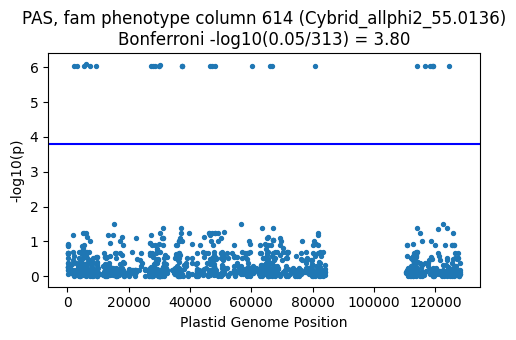

In [ ]:
import matplotlib.pyplot as plt
g = pd.read_csv(f'output/{prefix}_MAF_0_614.assoc.txt', sep=r'\s+')
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(g['ps'], -np.log10(g['p_wald']), s=8)
ax.axhline(threshold, color='blue')
ax.set_xlabel('Plastid Genome Position'); ax.set_ylabel('-log10(p)')
ax.set_title(f'PAS, fam phenotype column 614 ({summ.columns[614]})\nBonferroni -log10(0.05/{n_unique}) = {threshold:.2f}')
fig.tight_layout(); fig.savefig('manhattan_614.png', dpi=150)
plt.show()

## 13. Result table and CSV export
Summary of the 9 fitted traits: number of SNPs tested and how many pass the 3.797 Bonferroni threshold. The full per-SNP −log₁₀(p) values for the 9 traits are exported as CSV inside the Colab workspace.

In [ ]:
rows = []
for n in traits:
    g = pd.read_csv(f'output/{prefix}_MAF_0_{n}.assoc.txt', sep=r'\s+')
    l10 = -np.log10(g['p_wald'].values)
    rows.append({'fam_phenotype_column': n, 'trait': summ.columns[n],
                 'snps_tested': len(g), 'max_log10p': float(np.nanmax(l10)),
                 'snps_over_bonferroni_3_797': int(np.nansum(l10 > threshold))})
tbl = pd.DataFrame(rows)
tbl.to_csv('PAS_subset_results.csv', index=False)
tbl

,fam_phenotype_column,trait,snps_tested,max_log10p,snps_over_bonferroni_3_797
0,1,Cybrid_allfvfm_0.0,1202,4.043920,1
1,2,Cybrid_allfvfm_24.0,1202,3.226371,0
2,3,Cybrid_allfvfm_48.0,1202,2.259715,0
3,4,Cybrid_allfvfm_72.0,1202,2.588807,0
4,5,Cybrid_allfvfm_96.0,1202,3.479106,0
5,6,Cybrid_allfvfm_120.0,1202,2.607272,0
6,7,Cybrid_allgrowth_0.0,1202,4.084206,28
7,8,Cybrid_allgrowth_1.0019,1202,4.164492,28
8,614,Cybrid_allphi2_55.0136,1202,6.093416,29


## 14. Interpretation and validation record
**What was executed (fresh standard CPU Colab runtime):** PLINK 1.9 conversion of the authors' filtered 60-cybrid chloroplast VCF (7,041 variant lines; GEMMA tests the SNPs with complete genotypes, matching the row count of the authors' saved summary), the authors' own R fam-merge script (output **byte-identical** to their saved `..._additive_phenotypes.fam`), GEMMA 0.98.5 kinship (max deviation from the authors' saved matrix printed in §8), and 9 GEMMA LMM fits whose −log₁₀(p) match the authors' saved `sumarizing_PAS_results_MAF_0.csv` columns (exact deviations printed in §11). The 313 unique chloroplast variant combinations reproduce the paper's 3.8 Bonferroni LOD threshold.

**Differences from the paper:** only 9 of 1986 traits are fitted (identical command per trait); the MAF 0.04 sweep and the 1,531-accession nuclear GWAS are not reproduced; the Manhattan plot uses matplotlib instead of the authors' ggplot (same axes, data and threshold).

**AI-assisted parts:** the Python blocks for VCF parsing/unique-combination counting, GEMMA orchestration and Manhattan plotting reimplement the authors' R/CLI logic and were validated against the authors' saved outputs; the fam-merge (§7) is the authors' unmodified R script. AI-assisted translation from R/shell: the authors did not provide this Colab implementation; the executed example and listed checks were validated, but untested behavior is not guaranteed.

**References:** Theeuwen et al. 2024, bioRxiv 2024.07.12.603232; data Zenodo 11259865 (CC-BY-4.0); code git.wur.nl/tom.theeuwen/novel-cybrids; PLINK 1.9 (cog-genomics, 2026-09-27 build); GEMMA v0.98.5.